In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [2]:
class LinearSVM:
    def __init__(self, C=1.0, learning_rate=0.001, n_epochs=1000):
        """
        Linear Support Vector Machine using gradient descent
        
        Parameters:
        -----------
        C : float
            Regularization parameter (larger C = less regularization)
        learning_rate : float
            Learning rate for gradient descent
        n_epochs : int
            Number of training epochs
        """
        self.C = C
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.w = None
        self.b = None
        self.loss_history = []
        
    def compute_loss(self, X, y):
        """
        Compute SVM loss (hinge loss + regularization)
        
        Loss = (1/2)||w||^2 + C * sum(max(0, 1 - y_i * (w^T x_i + b)))
        """
        n_samples = X.shape[0]
        
        # Compute predictions
        predictions = X @ self.w + self.b
        
        # Hinge loss: max(0, 1 - y * prediction)
        margins = y * predictions
        hinge_loss = torch.clamp(1 - margins, min=0)
        
        # Total loss = regularization + C * average hinge loss
        regularization = 0.5 * torch.sum(self.w ** 2)
        loss = regularization + self.C * torch.sum(hinge_loss) / n_samples
        
        return loss
    
    def compute_gradients(self, X, y):
        """
        Compute gradients for weights and bias
        """
        n_samples = X.shape[0]
        
        # Compute predictions
        predictions = X @ self.w + self.b
        margins = y * predictions
        
        # Gradient of regularization term
        dw = self.w.clone()
        db = torch.tensor(0.0)
        
        # Add gradients from hinge loss
        # If margin < 1 (misclassified or within margin): add gradient
        for i in range(n_samples):
            if margins[i] < 1:
                dw -= self.C * y[i] * X[i] / n_samples
                db -= self.C * y[i] / n_samples
        
        return dw, db
    
    def fit(self, X, y, verbose=True):
        """
        Train the SVM
        
        Parameters:
        -----------
        X : torch.Tensor
            Training data of shape (n_samples, n_features)
        y : torch.Tensor
            Labels of shape (n_samples,) with values {-1, +1}
        verbose : bool
            Print training progress
        """
        n_samples, n_features = X.shape
        
        # Convert labels to {-1, +1} if needed
        y_transformed = torch.where(y == 0, torch.tensor(-1.0), torch.tensor(1.0))
        
        # Initialize weights
        self.w = torch.zeros(n_features, requires_grad=False)
        self.b = torch.tensor(0.0, requires_grad=False)
        
        if verbose:
            print(f"Training Linear SVM")
            print(f"C (regularization): {self.C}")
            print(f"Learning rate: {self.learning_rate}")
            print(f"Epochs: {self.n_epochs}\n")
        
        # Training loop
        for epoch in range(self.n_epochs):
            # Compute loss
            loss = self.compute_loss(X, y_transformed)
            self.loss_history.append(loss.item())
            
            # Compute gradients
            dw, db = self.compute_gradients(X, y_transformed)
            
            # Update parameters
            self.w -= self.learning_rate * dw
            self.b -= self.learning_rate * db
            
            # Print progress
            if verbose and (epoch % 100 == 0 or epoch == self.n_epochs - 1):
                accuracy = self.score(X, y)
                print(f"Epoch {epoch:4d}: Loss = {loss.item():.4f}, Accuracy = {accuracy*100:.2f}%")
        
        if verbose:
            print("\nTraining completed!")
            self._print_support_vectors(X, y_transformed)
        
        return self
    
    def _print_support_vectors(self, X, y):
        """
        Identify and print support vectors
        """
        predictions = X @ self.w + self.b
        margins = y * predictions
        
        # Support vectors have margin <= 1 + small tolerance
        support_vector_indices = (margins <= 1.01).nonzero(as_tuple=True)[0]
        
        print(f"\nSupport Vectors: {len(support_vector_indices)} out of {len(X)} samples")
        print(f"Support vector indices: {support_vector_indices.tolist()[:10]}..." if len(support_vector_indices) > 10 else f"Support vector indices: {support_vector_indices.tolist()}")
    
    def predict(self, X):
        """
        Predict class labels
        
        Returns:
        --------
        predictions : torch.Tensor
            Predicted labels {0, 1}
        """
        decision = X @ self.w + self.b
        # Convert back to {0, 1}
        predictions = torch.where(decision >= 0, torch.tensor(1), torch.tensor(0))
        return predictions
    
    def decision_function(self, X):
        """
        Compute decision function values (distance from hyperplane)
        """
        return X @ self.w + self.b
    
    def score(self, X, y):
        """
        Compute accuracy
        """
        predictions = self.predict(X)
        accuracy = (predictions == y).float().mean().item()
        return accuracy
    
    def get_hyperplane_params(self):
        """
        Get hyperplane parameters for visualization
        """
        return self.w, self.b

In [3]:
def generate_linearly_separable_data(n_samples=100):
    """
    Generate linearly separable 2D data
    """
    # Class 0
    X0 = torch.randn(n_samples // 2, 2) * 0.5 + torch.tensor([1.5, 1.5])
    y0 = torch.zeros(n_samples // 2, dtype=torch.long)
    
    # Class 1
    X1 = torch.randn(n_samples // 2, 2) * 0.5 + torch.tensor([-1.5, -1.5])
    y1 = torch.ones(n_samples // 2, dtype=torch.long)
    
    # Combine
    X = torch.cat([X0, X1], dim=0)
    y = torch.cat([y0, y1], dim=0)
    
    # Shuffle
    indices = torch.randperm(n_samples)
    X = X[indices]
    y = y[indices]
    
    return X, y

# Generate data
X, y = generate_linearly_separable_data(n_samples=100)

print(f"Data shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Class distribution: Class 0: {(y == 0).sum().item()}, Class 1: {(y == 1).sum().item()}")

Data shape: torch.Size([100, 2])
Labels shape: torch.Size([100])
Class distribution: Class 0: 50, Class 1: 50


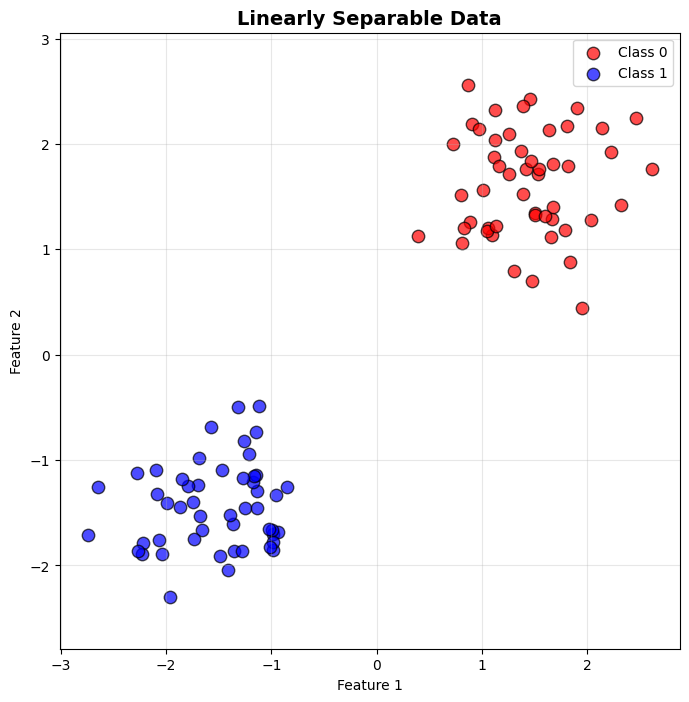

In [4]:
# Visualize data
plt.figure(figsize=(8, 8))
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Class 0', s=80, alpha=0.7, edgecolors='black')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', s=80, alpha=0.7, edgecolors='black')
plt.title('Linearly Separable Data', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [5]:
print("=" * 60)
print("TRAINING LINEAR SVM")
print("=" * 60 + "\n")

# Create and train SVM
svm = LinearSVM(C=1.0, learning_rate=0.001, n_epochs=1000)
svm.fit(X, y, verbose=True)

TRAINING LINEAR SVM

Training Linear SVM
C (regularization): 1.0
Learning rate: 0.001
Epochs: 1000

Epoch    0: Loss = 1.0000, Accuracy = 100.00%
Epoch  100: Loss = 0.5887, Accuracy = 100.00%
Epoch  200: Loss = 0.2850, Accuracy = 100.00%
Epoch  300: Loss = 0.2049, Accuracy = 100.00%
Epoch  400: Loss = 0.1933, Accuracy = 100.00%
Epoch  500: Loss = 0.1912, Accuracy = 100.00%
Epoch  600: Loss = 0.1902, Accuracy = 100.00%
Epoch  700: Loss = 0.1899, Accuracy = 100.00%
Epoch  800: Loss = 0.1899, Accuracy = 100.00%
Epoch  900: Loss = 0.1898, Accuracy = 100.00%
Epoch  999: Loss = 0.1898, Accuracy = 100.00%

Training completed!

Support Vectors: 36 out of 100 samples
Support vector indices: [3, 6, 14, 17, 20, 25, 27, 28, 30, 33]...


In [6]:
# Evaluate
predictions = svm.predict(X)
accuracy = svm.score(X, y)

print(f"\nFinal Accuracy: {accuracy * 100:.2f}%")
print(f"Correctly classified: {(predictions == y).sum().item()} / {len(y)}")
print(f"\nHyperplane: w = {svm.w.tolist()}, b = {svm.b.item():.4f}")


Final Accuracy: 100.00%
Correctly classified: 100 / 100

Hyperplane: w = [-0.3666335940361023, -0.36961621046066284], b = 0.0202


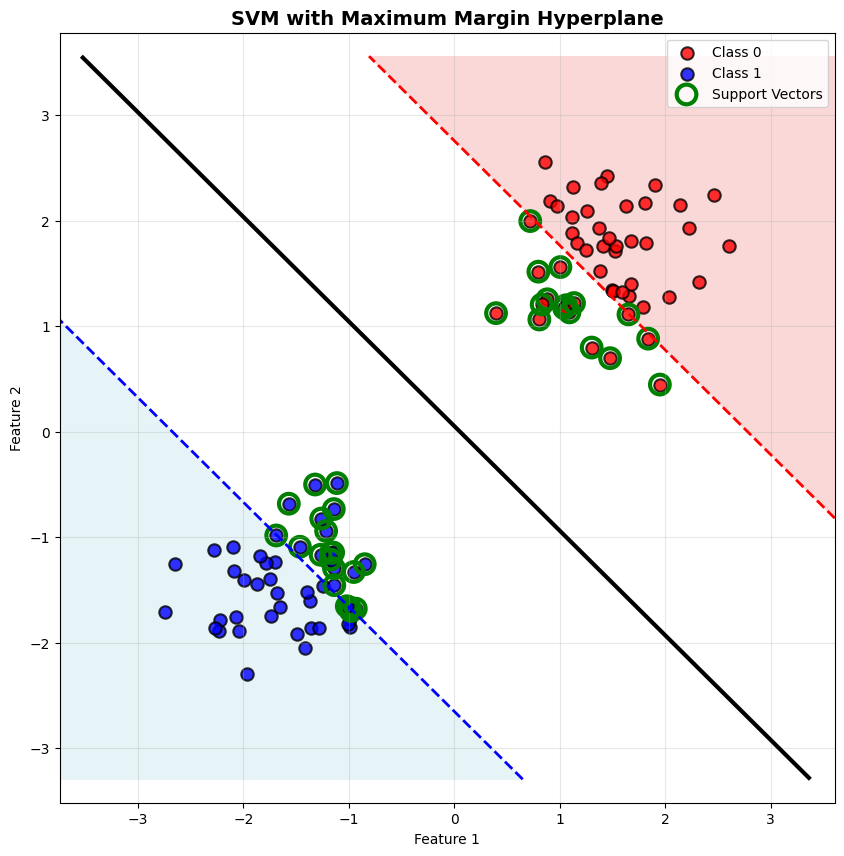

The solid black line is the decision boundary.
The dashed lines show the margins.
Green circles highlight support vectors (points on or within the margin).


In [7]:
def plot_svm_decision_boundary(X, y, svm_model, title="SVM Decision Boundary"):
    """
    Plot SVM decision boundary with margins and support vectors
    """
    plt.figure(figsize=(10, 10))
    
    # Create mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    # Compute decision function for mesh
    grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    Z = svm_model.decision_function(grid_points)
    Z = Z.reshape(xx.shape).detach().numpy()
    
    # Plot decision boundary and margins
    plt.contourf(xx, yy, Z, levels=[-np.inf, -1, 1, np.inf], 
                 colors=['lightcoral', 'white', 'lightblue'], alpha=0.3)
    plt.contour(xx, yy, Z, levels=[-1, 0, 1], 
               colors=['red', 'black', 'blue'], 
               linewidths=[2, 3, 2],
               linestyles=['--', '-', '--'])
    
    # Identify support vectors
    y_transformed = torch.where(y == 0, torch.tensor(-1.0), torch.tensor(1.0))
    predictions = svm_model.decision_function(X)
    margins = y_transformed * predictions
    support_vectors = (margins <= 1.01).nonzero(as_tuple=True)[0]
    
    # Plot data points
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Class 0', 
                s=80, alpha=0.8, edgecolors='black', linewidths=1.5)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', 
                s=80, alpha=0.8, edgecolors='black', linewidths=1.5)
    
    # Highlight support vectors
    plt.scatter(X[support_vectors, 0], X[support_vectors, 1], 
                s=200, facecolors='none', edgecolors='green', 
                linewidths=3, label='Support Vectors')
    
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.show()

# Plot
plot_svm_decision_boundary(X, y, svm, "SVM with Maximum Margin Hyperplane")

print("The solid black line is the decision boundary.")
print("The dashed lines show the margins.")
print("Green circles highlight support vectors (points on or within the margin).")

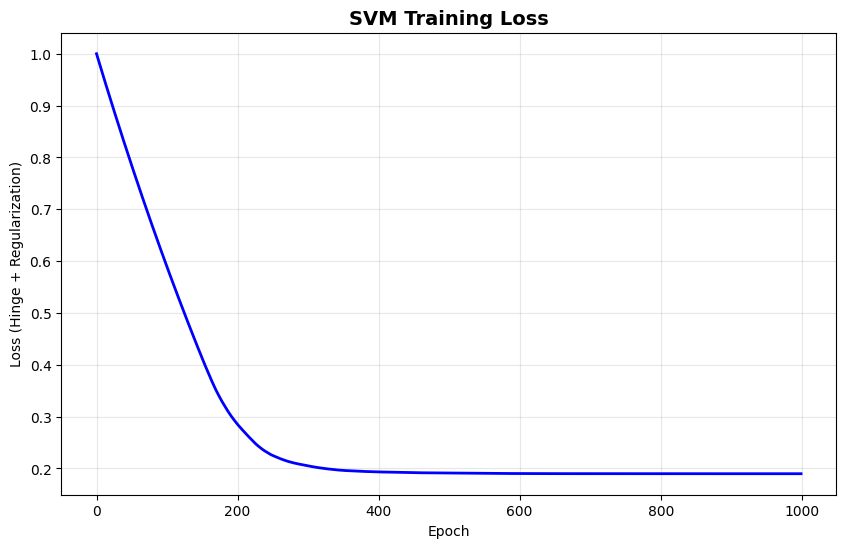

Initial loss: 1.0000
Final loss: 0.1898


In [8]:
# Plot loss curve
plt.figure(figsize=(10, 6))
plt.plot(svm.loss_history, 'b-', linewidth=2)
plt.title('SVM Training Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (Hinge + Regularization)')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial loss: {svm.loss_history[0]:.4f}")
print(f"Final loss: {svm.loss_history[-1]:.4f}")

Training SVM with C = 0.1...
Training SVM with C = 1.0...
Training SVM with C = 10.0...
Training SVM with C = 100.0...


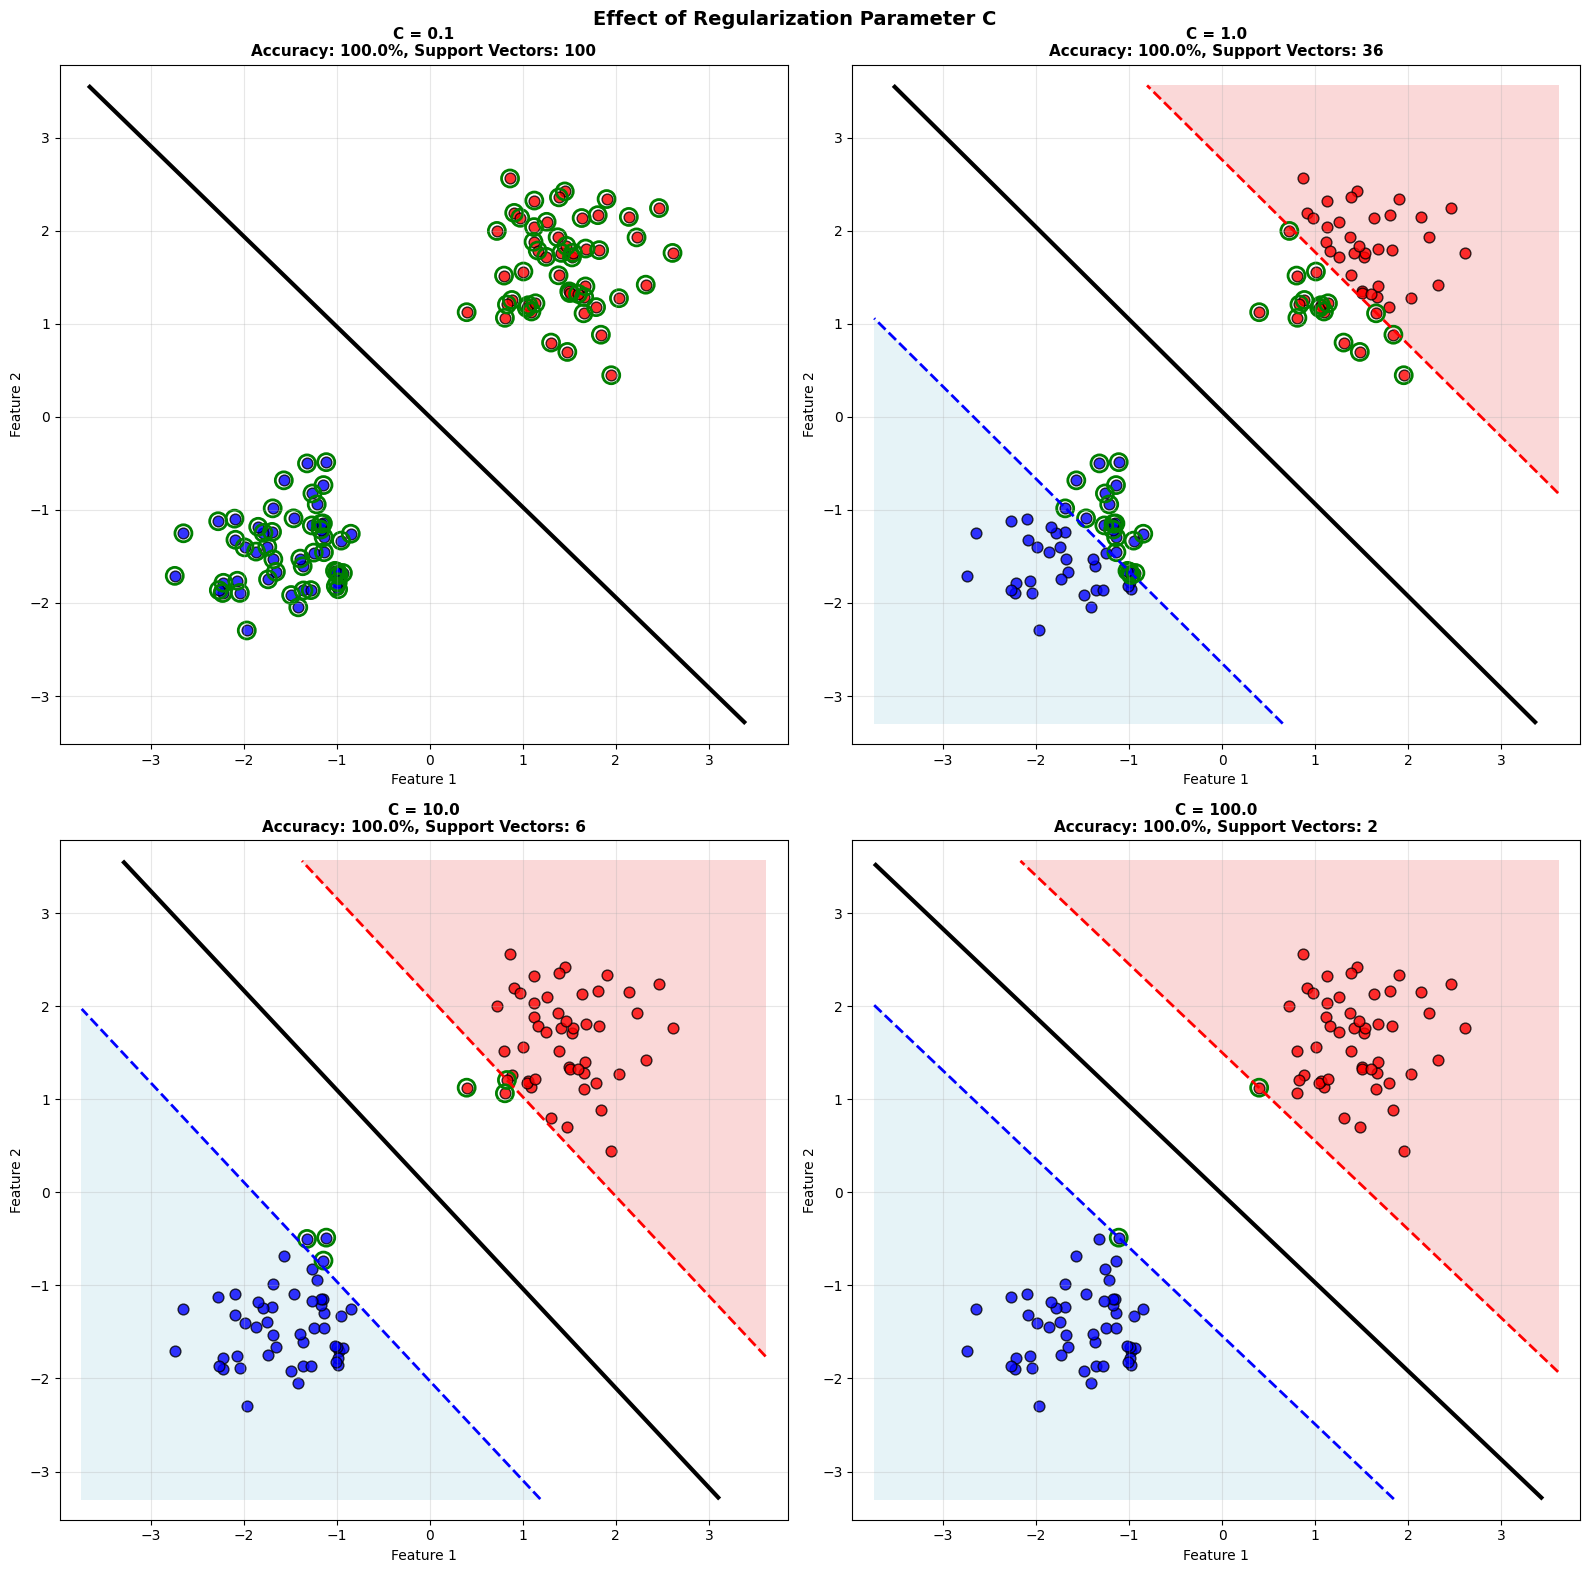


Small C = more regularization = wider margin = more support vectors
Large C = less regularization = narrower margin = fewer support vectors


In [9]:
# Compare different C values
C_values = [0.1, 1.0, 10.0, 100.0]

fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

for idx, C in enumerate(C_values):
    print(f"Training SVM with C = {C}...")
    
    # Train model
    model = LinearSVM(C=C, learning_rate=0.001, n_epochs=1000)
    model.fit(X, y, verbose=False)
    
    # Plot on subplot
    ax = axes[idx]
    
    # Create mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    Z = model.decision_function(grid_points).reshape(xx.shape).detach().numpy()
    
    # Plot
    ax.contourf(xx, yy, Z, levels=[-np.inf, -1, 1, np.inf], 
                colors=['lightcoral', 'white', 'lightblue'], alpha=0.3)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], 
               colors=['red', 'black', 'blue'], 
               linewidths=[2, 3, 2],
               linestyles=['--', '-', '--'])
    
    # Support vectors
    y_transformed = torch.where(y == 0, torch.tensor(-1.0), torch.tensor(1.0))
    margins = y_transformed * model.decision_function(X)
    support_vectors = (margins <= 1.01).nonzero(as_tuple=True)[0]
    
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='red', s=60, alpha=0.8, edgecolors='black')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', s=60, alpha=0.8, edgecolors='black')
    ax.scatter(X[support_vectors, 0], X[support_vectors, 1], 
               s=150, facecolors='none', edgecolors='green', linewidths=2)
    
    accuracy = model.score(X, y)
    ax.set_title(f'C = {C}\nAccuracy: {accuracy*100:.1f}%, Support Vectors: {len(support_vectors)}', 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

plt.suptitle('Effect of Regularization Parameter C', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nSmall C = more regularization = wider margin = more support vectors")
print("Large C = less regularization = narrower margin = fewer support vectors")

In [10]:
print("=" * 70)
print("SIMPLE 4-POINT EXAMPLE")
print("=" * 70)

# Simple dataset
X_simple = torch.tensor([
    [1.0, 2.0],
    [2.0, 3.0],
    [-1.0, -1.0],
    [-2.0, -2.0]
])

y_simple = torch.tensor([1, 1, 0, 0])

print("\nData:")
print(f"{'Point':<8} {'X1':<8} {'X2':<8} {'Class'}")
print("-" * 32)
for i in range(len(X_simple)):
    print(f"{i+1:<8} {X_simple[i, 0].item():<8.1f} {X_simple[i, 1].item():<8.1f} {y_simple[i].item()}")

print("\n" + "=" * 70)
print("Training SVM...")
print("=" * 70 + "\n")

# Train SVM
svm_simple = LinearSVM(C=1.0, learning_rate=0.01, n_epochs=500)
svm_simple.fit(X_simple, y_simple, verbose=True)

SIMPLE 4-POINT EXAMPLE

Data:
Point    X1       X2       Class
--------------------------------
1        1.0      2.0      1
2        2.0      3.0      1
3        -1.0     -1.0     0
4        -2.0     -2.0     0

Training SVM...

Training Linear SVM
C (regularization): 1.0
Learning rate: 0.01
Epochs: 500

Epoch    0: Loss = 1.0000, Accuracy = 100.00%
Epoch  100: Loss = 0.1737, Accuracy = 100.00%
Epoch  200: Loss = 0.1552, Accuracy = 100.00%
Epoch  300: Loss = 0.1541, Accuracy = 100.00%
Epoch  400: Loss = 0.1540, Accuracy = 100.00%
Epoch  499: Loss = 0.1552, Accuracy = 100.00%

Training completed!

Support Vectors: 2 out of 4 samples
Support vector indices: [0, 2]


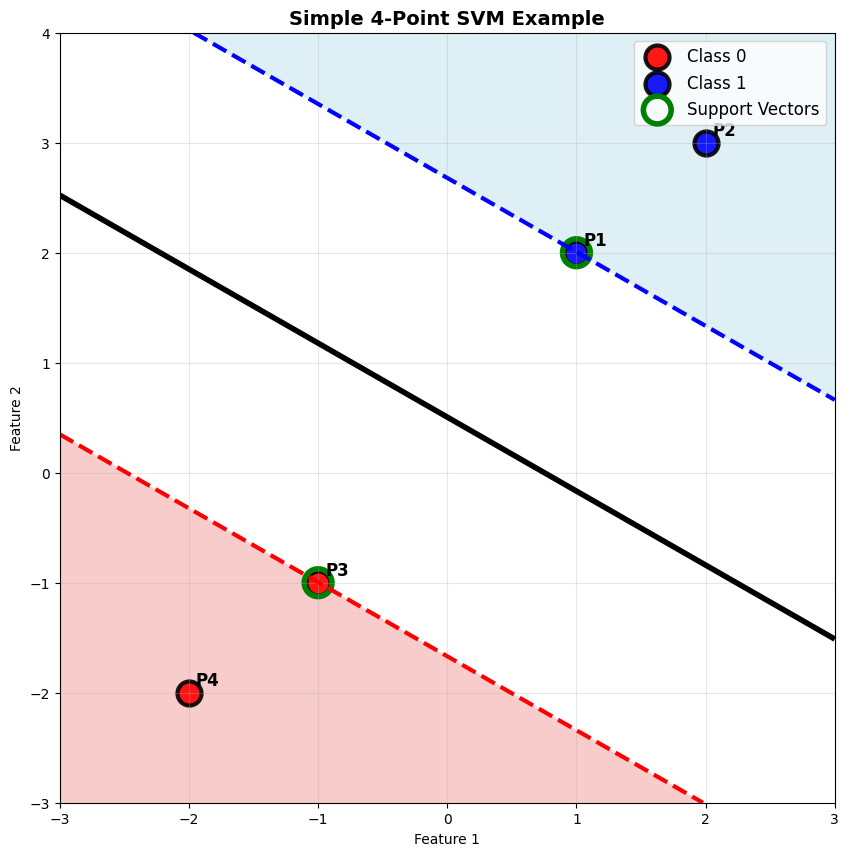


RESULTS

Learned Hyperplane:
  w = [0.3093, 0.4599]
  b = -0.2325

Decision function: f(x) = 0.3093*x1 + 0.4599*x2 + -0.2325

Point    X1       X2       True     Pred     Decision     Status
1        1.0      2.0      1        1        0.9967       ✓ (SV)
2        2.0      3.0      1        1        1.7659       ✓ 
3        -1.0     -1.0     0        0        -1.0018      ✓ (SV)
4        -2.0     -2.0     0        0        -1.7710      ✓ 


In [11]:
# Visualize simple example
plt.figure(figsize=(10, 10))

# Create mesh
x_min, x_max = -3, 3
y_min, y_max = -3, 4
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
Z = svm_simple.decision_function(grid_points).reshape(xx.shape).detach().numpy()

# Plot decision regions and margins
plt.contourf(xx, yy, Z, levels=[-np.inf, -1, 1, np.inf], 
             colors=['lightcoral', 'white', 'lightblue'], alpha=0.4)
plt.contour(xx, yy, Z, levels=[-1, 0, 1], 
           colors=['red', 'black', 'blue'], 
           linewidths=[3, 4, 3],
           linestyles=['--', '-', '--'])

# Plot points
plt.scatter(X_simple[y_simple == 0, 0], X_simple[y_simple == 0, 1], 
           c='red', s=300, alpha=0.9, edgecolors='black', linewidths=3, label='Class 0')
plt.scatter(X_simple[y_simple == 1, 0], X_simple[y_simple == 1, 1], 
           c='blue', s=300, alpha=0.9, edgecolors='black', linewidths=3, label='Class 1')

# Annotate points
for i, point in enumerate(X_simple):
    plt.annotate(f'P{i+1}', xy=point, xytext=(5, 5), textcoords='offset points',
                fontsize=12, fontweight='bold')

# Identify support vectors
y_transformed = torch.where(y_simple == 0, torch.tensor(-1.0), torch.tensor(1.0))
margins = y_transformed * svm_simple.decision_function(X_simple)
support_vectors = (margins <= 1.01).nonzero(as_tuple=True)[0]
plt.scatter(X_simple[support_vectors, 0], X_simple[support_vectors, 1], 
           s=400, facecolors='none', edgecolors='green', linewidths=4, label='Support Vectors')

plt.title('Simple 4-Point SVM Example', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.show()

# Print results
print("\n" + "=" * 70)
print("RESULTS")
print("=" * 70)

print(f"\nLearned Hyperplane:")
print(f"  w = [{svm_simple.w[0].item():.4f}, {svm_simple.w[1].item():.4f}]")
print(f"  b = {svm_simple.b.item():.4f}")
print(f"\nDecision function: f(x) = {svm_simple.w[0].item():.4f}*x1 + {svm_simple.w[1].item():.4f}*x2 + {svm_simple.b.item():.4f}")

print(f"\n{'Point':<8} {'X1':<8} {'X2':<8} {'True':<8} {'Pred':<8} {'Decision':<12} {'Status'}")
print("=" * 70)
for i in range(len(X_simple)):
    pred = svm_simple.predict(X_simple[i:i+1])[0].item()
    decision = svm_simple.decision_function(X_simple[i:i+1])[0].item()
    status = "✓" if pred == y_simple[i].item() else "✗"
    is_sv = "(SV)" if i in support_vectors else ""
    print(f"{i+1:<8} {X_simple[i, 0].item():<8.1f} {X_simple[i, 1].item():<8.1f} {y_simple[i].item():<8} {pred:<8} {decision:<12.4f} {status} {is_sv}")

In [12]:
class KernelSVM:
    def __init__(self, C=1.0, gamma=0.5, learning_rate=0.001, n_epochs=1000):
        """
        Kernel SVM with RBF (Radial Basis Function) kernel
        
        RBF Kernel: K(x, x') = exp(-gamma * ||x - x'||^2)
        
        Parameters:
        -----------
        C : float
            Regularization parameter
        gamma : float
            RBF kernel parameter (larger = more complex boundary)
        learning_rate : float
            Learning rate
        n_epochs : int
            Training epochs
        """
        self.C = C
        self.gamma = gamma
        self.learning_rate = learning_rate
        self.n_epochs = n_epochs
        self.alpha = None  # Dual variables
        self.b = None
        self.X_train = None
        self.y_train = None
        self.loss_history = []
    
    def rbf_kernel(self, X1, X2):
        """
        Compute RBF kernel matrix
        K(x_i, x_j) = exp(-gamma * ||x_i - x_j||^2)
        """
        # Compute pairwise squared distances
        X1_norm = (X1 ** 2).sum(dim=1).view(-1, 1)
        X2_norm = (X2 ** 2).sum(dim=1).view(1, -1)
        distances_sq = X1_norm + X2_norm - 2 * X1 @ X2.T
        
        # RBF kernel
        K = torch.exp(-self.gamma * distances_sq)
        return K
    
    def fit(self, X, y, verbose=True):
        """
        Train kernel SVM using simplified gradient descent on dual variables
        """
        n_samples = X.shape[0]
        
        # Store training data
        self.X_train = X.clone()
        self.y_train = torch.where(y == 0, torch.tensor(-1.0), torch.tensor(1.0))
        
        # Initialize dual variables (alpha)
        self.alpha = torch.zeros(n_samples)
        self.b = torch.tensor(0.0)
        
        # Compute kernel matrix
        K = self.rbf_kernel(X, X)
        
        if verbose:
            print(f"Training Kernel SVM (RBF)")
            print(f"C: {self.C}, gamma: {self.gamma}")
            print(f"Learning rate: {self.learning_rate}")
            print(f"Epochs: {self.n_epochs}\n")
        
        # Training loop
        for epoch in range(self.n_epochs):
            # Compute predictions
            predictions = (self.alpha * self.y_train) @ K + self.b
            margins = self.y_train * predictions
            
            # Compute loss (simplified)
            hinge_loss = torch.clamp(1 - margins, min=0).sum()
            loss = 0.5 * (self.alpha @ K @ self.alpha) + self.C * hinge_loss / n_samples
            self.loss_history.append(loss.item())
            
            # Update alpha for misclassified points
            for i in range(n_samples):
                if margins[i] < 1:
                    self.alpha[i] += self.learning_rate * self.C / n_samples
                    self.b += self.learning_rate * self.C * self.y_train[i] / n_samples
            
            # Clip alpha to [0, C]
            self.alpha = torch.clamp(self.alpha, 0, self.C)
            
            if verbose and (epoch % 100 == 0 or epoch == self.n_epochs - 1):
                accuracy = self.score(X, y)
                n_sv = (self.alpha > 1e-5).sum().item()
                print(f"Epoch {epoch:4d}: Loss = {loss.item():.4f}, Accuracy = {accuracy*100:.2f}%, SVs = {n_sv}")
        
        if verbose:
            print("\nTraining completed!")
            support_vectors = (self.alpha > 1e-5).nonzero(as_tuple=True)[0]
            print(f"Support Vectors: {len(support_vectors)} out of {n_samples} samples")
        
        return self
    
    def decision_function(self, X):
        """
        Compute decision function using kernel
        """
        K = self.rbf_kernel(X, self.X_train)
        return K @ (self.alpha * self.y_train) + self.b
    
    def predict(self, X):
        """
        Predict class labels
        """
        decision = self.decision_function(X)
        return torch.where(decision >= 0, torch.tensor(1), torch.tensor(0))
    
    def score(self, X, y):
        """
        Compute accuracy
        """
        predictions = self.predict(X)
        return (predictions == y).float().mean().item()

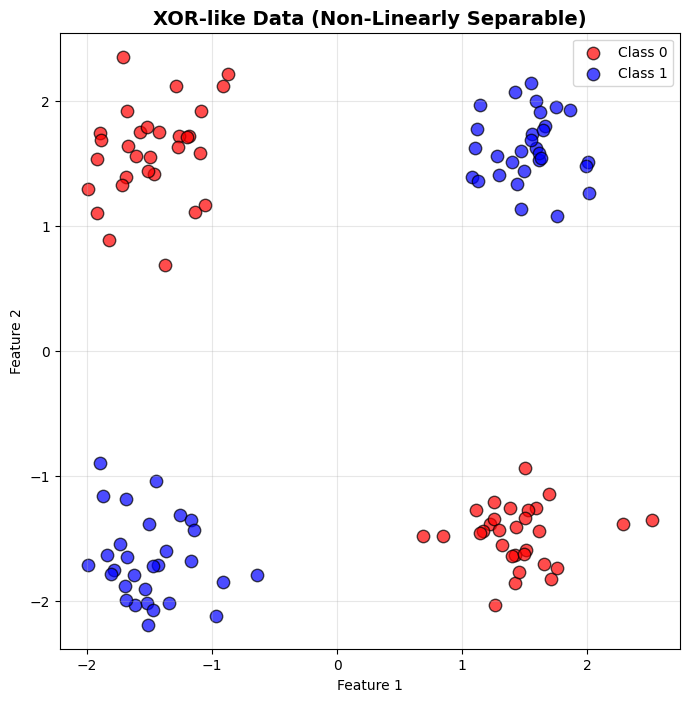

This data cannot be separated by a straight line!
We need a kernel SVM.


In [13]:
# Generate XOR-like data (non-linearly separable)
def generate_xor_data(n_samples=100):
    """
    Generate XOR-like non-linearly separable data
    """
    n = n_samples // 4
    
    # Quadrant 1 (top-right): Class 1
    X1 = torch.randn(n, 2) * 0.3 + torch.tensor([1.5, 1.5])
    y1 = torch.ones(n, dtype=torch.long)
    
    # Quadrant 2 (top-left): Class 0
    X2 = torch.randn(n, 2) * 0.3 + torch.tensor([-1.5, 1.5])
    y2 = torch.zeros(n, dtype=torch.long)
    
    # Quadrant 3 (bottom-left): Class 1
    X3 = torch.randn(n, 2) * 0.3 + torch.tensor([-1.5, -1.5])
    y3 = torch.ones(n, dtype=torch.long)
    
    # Quadrant 4 (bottom-right): Class 0
    X4 = torch.randn(n, 2) * 0.3 + torch.tensor([1.5, -1.5])
    y4 = torch.zeros(n, dtype=torch.long)
    
    X = torch.cat([X1, X2, X3, X4], dim=0)
    y = torch.cat([y1, y2, y3, y4], dim=0)
    
    # Shuffle
    indices = torch.randperm(len(X))
    X = X[indices]
    y = y[indices]
    
    return X, y

# Generate XOR data
X_xor, y_xor = generate_xor_data(n_samples=120)

# Visualize
plt.figure(figsize=(8, 8))
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], 
           c='red', label='Class 0', s=80, alpha=0.7, edgecolors='black')
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], 
           c='blue', label='Class 1', s=80, alpha=0.7, edgecolors='black')
plt.title('XOR-like Data (Non-Linearly Separable)', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

print("This data cannot be separated by a straight line!")
print("We need a kernel SVM.")

In [14]:
# Train Kernel SVM
print("\n" + "=" * 60)
print("TRAINING KERNEL SVM (RBF)")
print("=" * 60 + "\n")

kernel_svm = KernelSVM(C=1.0, gamma=0.5, learning_rate=0.01, n_epochs=500)
kernel_svm.fit(X_xor, y_xor, verbose=True)


TRAINING KERNEL SVM (RBF)

Training Kernel SVM (RBF)
C: 1.0, gamma: 0.5
Learning rate: 0.01
Epochs: 500

Epoch    0: Loss = 1.0000, Accuracy = 100.00%, SVs = 120
Epoch  100: Loss = 0.9066, Accuracy = 100.00%, SVs = 120
Epoch  200: Loss = 1.0324, Accuracy = 100.00%, SVs = 120
Epoch  300: Loss = 1.3774, Accuracy = 100.00%, SVs = 120
Epoch  400: Loss = 1.9415, Accuracy = 100.00%, SVs = 120
Epoch  499: Loss = 2.5740, Accuracy = 100.00%, SVs = 120

Training completed!
Support Vectors: 120 out of 120 samples


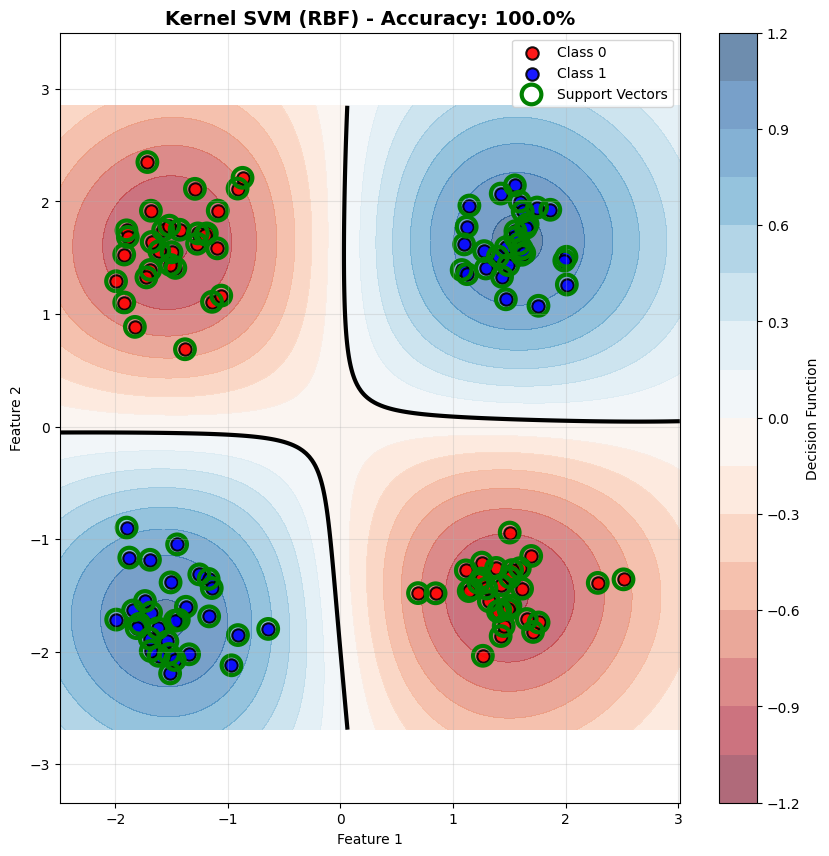


Kernel SVM successfully learned a non-linear decision boundary!
Accuracy: 100.00%
Support Vectors: 120 out of 120


In [15]:
# Visualize kernel SVM results
plt.figure(figsize=(10, 10))

# Create mesh
x_min, x_max = X_xor[:, 0].min() - 0.5, X_xor[:, 0].max() + 0.5
y_min, y_max = X_xor[:, 1].min() - 0.5, X_xor[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid_points = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
Z = kernel_svm.decision_function(grid_points).reshape(xx.shape).detach().numpy()

# Plot decision boundary
plt.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.6)
plt.colorbar(label='Decision Function')
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=3)

# Plot data
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], 
           c='red', label='Class 0', s=80, alpha=0.9, edgecolors='black', linewidths=1.5)
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], 
           c='blue', label='Class 1', s=80, alpha=0.9, edgecolors='black', linewidths=1.5)

# Highlight support vectors
support_vectors = (kernel_svm.alpha > 1e-5).nonzero(as_tuple=True)[0]
plt.scatter(X_xor[support_vectors, 0], X_xor[support_vectors, 1], 
           s=200, facecolors='none', edgecolors='green', linewidths=3, label='Support Vectors')

accuracy = kernel_svm.score(X_xor, y_xor)
plt.title(f'Kernel SVM (RBF) - Accuracy: {accuracy*100:.1f}%', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

print(f"\nKernel SVM successfully learned a non-linear decision boundary!")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Support Vectors: {len(support_vectors)} out of {len(X_xor)}")